**Problem Statement**:Superstore has grown steadily over 2014–2017 — sales rose from $484K to $733K/year (a 20% jump in the final year alone) and order volume grew 28% YoY. On the surface, the business is expanding. But profit hasn't kept pace with sales, and a closer look at the transaction-level data reveals where value is being created and where it's quietly leaking out:

1.**Furniture drives 32% of sales but only ~6% of profit.**

2.**Discounting is eroding margin past a clear threshold.**

3.**Performance varies sharply by geography.**

4.**Nearly 1 in 5 line items (18.7%) lose money, suggesting the issue isn't isolated to a few products**

**Business Questions **


1. Which products generate the highest total losses?


2.Which sub-categories are responsible for the most losses?


3.Which products have high sales but negative profit?


4.At what discount level does profitability deteriorate?


5.Which category + sub-category combinations are most profitable?


6.Which customers have high sales but low profit margins?


7.Which states have high sales but poor profitability?


8.What percentage of transactions are loss-making?

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**1. Load Libraries & Dataset**

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")

DATA_PATH = "/content/drive/MyDrive/dataset/Superstore.csv"
df = pd.read_csv(DATA_PATH, encoding="latin1")
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(1)

Dataset loaded: 9,994 rows × 21 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91


 2 **Dataset Understanding**

In [ ]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
df.info()
print("\nNumerical summary:")
display(df.describe().T)
print("\nCategorical summary:")
display(df.describe(include="object").T)

Shape: (9994, 21)

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    

,count,mean,std,min,25%,50%,75%,max
Row ID,"9,994.00","4,997.50","2,885.16",1.00,"2,499.25","4,997.50","7,495.75","9,994.00"
Postal Code,"9,994.00","55,190.38","32,063.69","1,040.00","23,223.00","56,430.50","90,008.00","99,301.00"
Sales,"9,994.00",229.86,623.25,0.44,17.28,54.49,209.94,"22,638.48"
Quantity,"9,994.00",3.79,2.23,1.00,2.00,3.00,5.00,14.00
Discount,"9,994.00",0.16,0.21,0.00,0.00,0.20,0.20,0.80
Profit,"9,994.00",28.66,234.26,"-6,599.98",1.73,8.67,29.36,"8,399.98"



Categorical summary:


,count,unique,top,freq
Order ID,9994,5009,CA-2017-100111,14
Order Date,9994,1237,9/5/2016,38
Ship Date,9994,1334,12/16/2015,35
Ship Mode,9994,4,Standard Class,5968
Customer ID,9994,793,WB-21850,37
Customer Name,9994,793,William Brown,37
Segment,9994,3,Consumer,5191
Country,9994,1,United States,9994
City,9994,531,New York City,915
State,9994,49,California,2001


3.**Data Quality Assesment**

In [ ]:
quality = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Missing %": df.isna().mean().mul(100),
    "Unique Values": df.nunique()
}).sort_values("Missing Values", ascending=False)
display(quality)

print("Duplicate rows:", df.duplicated().sum())
print("Negative sales:", (df["Sales"] < 0).sum())
print("Non-positive quantity:", (df["Quantity"] <= 0).sum())
print("Negative discounts:", (df["Discount"] < 0).sum())

,Missing Values,Missing %,Unique Values
Row ID,0,0.00,9994
Order ID,0,0.00,5009
Order Date,0,0.00,1237
Ship Date,0,0.00,1334
Ship Mode,0,0.00,4
Customer ID,0,0.00,793
Customer Name,0,0.00,793
Segment,0,0.00,3
Country,0,0.00,1
City,0,0.00,531


Duplicate rows: 0
Negative sales: 0
Non-positive quantity: 0
Negative discounts: 0


In [ ]:
### Data-quality interpretation
#The checks above establish whether the dataset contains missing values, duplicate records, invalid numeric values, or
 #other issues before analysis. Any cleaning decision should be based on these results rather than assuming that a problem exists.

 4. **Data Cleaning & Feature Engineering**

In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%m/%d/%Y")

# Remove exact duplicate records if present
df = df.drop_duplicates().copy()

# Derived business fields
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["YearMonth"] = df["Order Date"].dt.to_period("M").astype(str)
df["Ship Days"] = (df["Ship Date"] - df["Order Date"]).dt.days
df["Profit Margin"] = np.where(df["Sales"] != 0, df["Profit"] / df["Sales"], np.nan)
df["Loss Making"] = df["Profit"] < 0

# Discount bands for business analysis
bins = [-0.01, 0, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]
labels = ["0%", "1-10%", "11-20%", "21-30%", "31-40%", "41-50%", "51-60%", "61-70%", "71-80%"]
df["Discount Band"] = pd.cut(df["Discount"], bins=bins, labels=labels, include_lowest=True)

print(f"Final dataset: {len(df):,} rows × {df.shape[1]} columns")
display(df.head())

Final dataset: 9,994 rows × 28 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Quantity,Discount,Profit,Year,Month,YearMonth,Ship Days,Profit Margin,Loss Making,Discount Band
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,2,0.00,41.91,2016,11,2016-11,3,0.16,False,0%
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,3,0.00,219.58,2016,11,2016-11,3,0.30,False,0%
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,2,0.00,6.87,2016,6,2016-06,4,0.47,False,0%
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,5,0.45,-383.03,2015,10,2015-10,7,-0.40,True,41-50%
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,2,0.20,2.52,2015,10,2015-10,7,0.11,False,11-20%


 5.**Executive KPI Analysis**

In [ ]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()
total_quantity = df["Quantity"].sum()
avg_order_value = total_sales / total_orders
avg_profit_order = total_profit / total_orders
avg_discount = df["Discount"].mean()
avg_ship_days = df["Ship Days"].mean()
loss_lines = df["Loss Making"].sum()

kpis = pd.DataFrame({
    "Metric": ["Total Sales", "Total Profit", "Profit Margin", "Orders", "Customers", "Quantity Sold", "Average Order Value",
               "Average Profit / Order", "Average Discount", "Average Ship Days", "Loss-making Line Items"],
    "Value": [total_sales, total_profit, total_profit/total_sales, total_orders, total_customers, total_quantity, avg_order_value,
              avg_profit_order, avg_discount, avg_ship_days, loss_lines]
})
display(kpis)

,Metric,Value
0,Total Sales,"2,297,200.86"
1,Total Profit,"286,397.02"
2,Profit Margin,0.12
3,Orders,"5,009.00"
4,Customers,793.00
5,Quantity Sold,"37,873.00"
6,Average Order Value,458.61
7,Average Profit / Order,57.18
8,Average Discount,0.16
9,Average Ship Days,3.96


6.**Time Series Performance**

,Sales,Profit,Profit Margin,Sales YoY %,Profit YoY %
Year,,,,,
2014,"484,247.50","49,543.97",0.10,NaN,NaN
2015,"470,532.51","61,618.60",0.13,-2.83,24.37
2016,"609,205.60","81,795.17",0.13,29.47,32.74
2017,"733,215.26","93,439.27",0.13,20.36,14.24


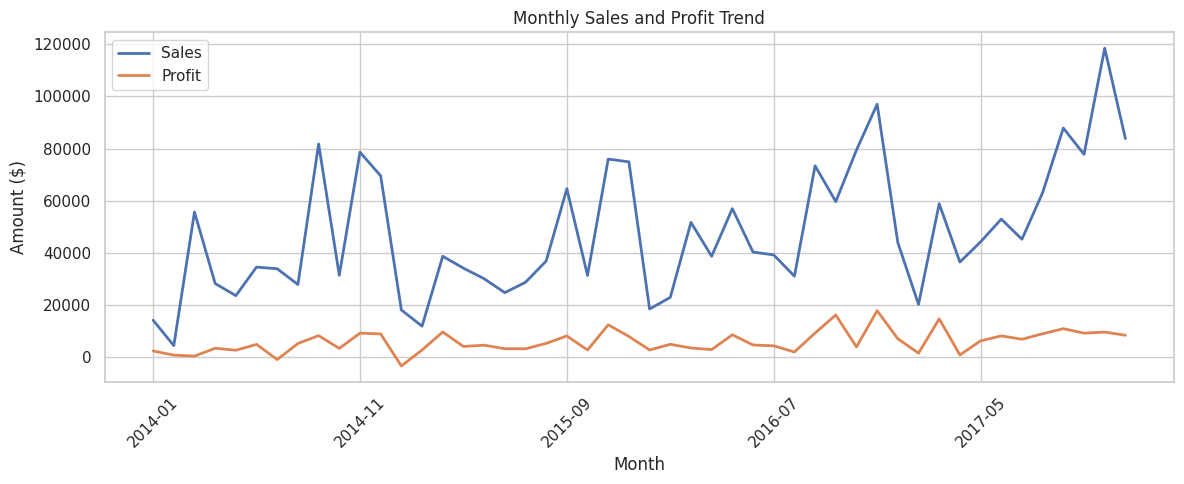

Top sales months:


,Sales
Month,
11,"352,461.07"
12,"325,293.50"
9,"307,649.95"


In [ ]:
yearly = df.groupby("Year").agg(Sales=("Sales","sum"), Profit=("Profit","sum"))
yearly["Profit Margin"] = yearly["Profit"] / yearly["Sales"]
yearly["Sales YoY %"] = yearly["Sales"].pct_change() * 100
yearly["Profit YoY %"] = yearly["Profit"].pct_change() * 100
display(yearly)

monthly = df.groupby("YearMonth").agg(Sales=("Sales","sum"), Profit=("Profit","sum"))
fig, ax = plt.subplots(figsize=(12,5))
monthly.plot(ax=ax, linewidth=2)
ax.set_title("Monthly Sales and Profit Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Amount ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

month_sales = df.groupby("Month")["Sales"].sum().sort_values(ascending=False)
print("Top sales months:")
display(month_sales.head(3))

7.**Category & Sub-Category Profitability**

,Sales,Profit,Quantity,Profit Margin %
Category,,,,
Technology,"836,154.03","145,454.95",6939,17.40
Office Supplies,"719,047.03","122,490.80",22906,17.04
Furniture,"741,999.80","18,451.27",8028,2.49


Bottom sub-categories by profit:


,Sales,Profit,Quantity,Profit Margin %
Sub-Category,,,,
Tables,"206,965.53","-17,725.48",1241,-8.56
Bookcases,"114,880.00","-3,472.56",868,-3.02
Supplies,"46,673.54","-1,189.10",647,-2.55
Fasteners,"3,024.28",949.52,914,31.40
Machines,"189,238.63","3,384.76",440,1.79
Labels,"12,486.31","5,546.25",1400,44.42
Art,"27,118.79","6,527.79",3000,24.07
Envelopes,"16,476.40","6,964.18",906,42.27
Furnishings,"91,705.16","13,059.14",3563,14.24


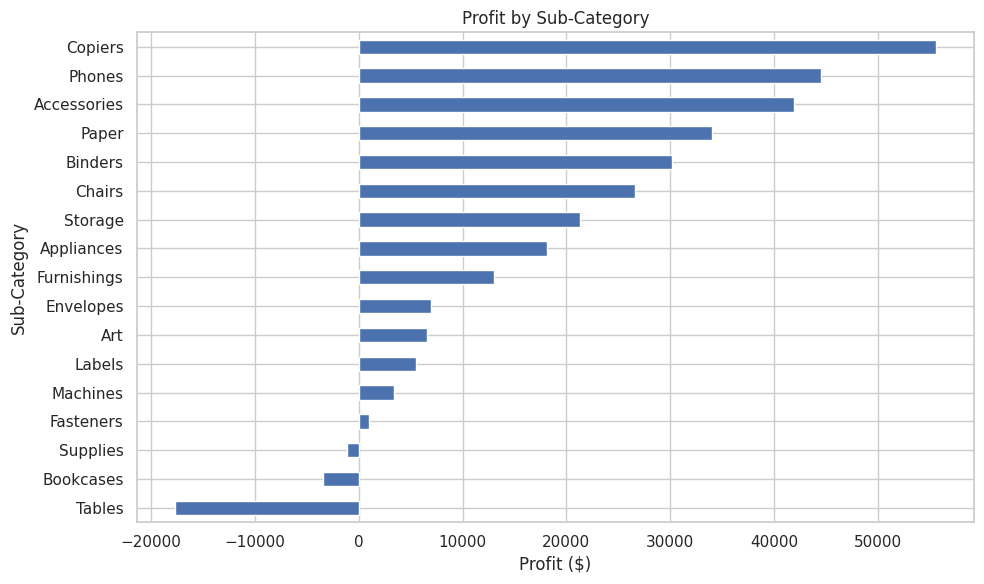

In [ ]:
category = df.groupby("Category").agg(Sales=("Sales","sum"), Profit=("Profit","sum"), Quantity=("Quantity","sum"))
category["Profit Margin %"] = category["Profit"] / category["Sales"] * 100
display(category.sort_values("Profit", ascending=False))

subcat = df.groupby("Sub-Category").agg(Sales=("Sales","sum"), Profit=("Profit","sum"), Quantity=("Quantity","sum"))
subcat["Profit Margin %"] = subcat["Profit"] / subcat["Sales"] * 100
print("Bottom sub-categories by profit:")
display(subcat.sort_values("Profit").head(10))

fig, ax = plt.subplots(figsize=(10,6))
subcat.sort_values("Profit")["Profit"].plot(kind="barh", ax=ax)
ax.set_title("Profit by Sub-Category")
ax.set_xlabel("Profit ($)")
plt.tight_layout()
plt.show()

8.**Product and customer Analysis**

In [ ]:
product = df.groupby("Product Name").agg(Sales=("Sales","sum"), Profit=("Profit","sum"), Quantity=("Quantity","sum"))
customer = df.groupby("Customer Name").agg(Sales=("Sales","sum"), Profit=("Profit","sum"), Orders=("Order ID","nunique"))

print("Top 10 products by sales")
display(product.sort_values("Sales", ascending=False).head(10))
print("\nBottom 10 products by profit")
display(product.sort_values("Profit").head(10))
print("\nTop 10 customers by sales")
display(customer.sort_values("Sales", ascending=False).head(10))
print("\nBottom 10 customers by profit")
display(customer.sort_values("Profit").head(10))

Top 10 products by sales


,Sales,Profit,Quantity
Product Name,,,
Canon imageCLASS 2200 Advanced Copier,"61,599.82","25,199.93",20
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,"27,453.38","7,753.04",31
Cisco TelePresence System EX90 Videoconferencing Unit,"22,638.48","-1,811.08",6
HON 5400 Series Task Chairs for Big and Tall,"21,870.58",0.00,39
GBC DocuBind TL300 Electric Binding System,"19,823.48","2,233.51",37
GBC Ibimaster 500 Manual ProClick Binding System,"19,024.50",760.98,48
Hewlett Packard LaserJet 3310 Copier,"18,839.69","6,983.88",38
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color","18,374.90","4,094.98",12
GBC DocuBind P400 Electric Binding System,"17,965.07","-1,878.17",27



Bottom 10 products by profit


,Sales,Profit,Quantity
Product Name,,,
Cubify CubeX 3D Printer Double Head Print,"11,099.96","-8,879.97",9
Lexmark MX611dhe Monochrome Laser Printer,"16,829.90","-4,589.97",18
Cubify CubeX 3D Printer Triple Head Print,"7,999.98","-3,839.99",4
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,"9,917.64","-2,876.12",27
Bush Advantage Collection Racetrack Conference Table,"9,544.73","-1,934.40",33
GBC DocuBind P400 Electric Binding System,"17,965.07","-1,878.17",27
Cisco TelePresence System EX90 Videoconferencing Unit,"22,638.48","-1,811.08",6
Martin Yale Chadless Opener Electric Letter Opener,"16,656.20","-1,299.18",22
Balt Solid Wood Round Tables,"6,518.75","-1,201.06",19



Top 10 customers by sales


,Sales,Profit,Orders
Customer Name,,,
Sean Miller,"25,043.05","-1,980.74",5
Tamara Chand,"19,052.22","8,981.32",5
Raymond Buch,"15,117.34","6,976.10",6
Tom Ashbrook,"14,595.62","4,703.79",4
Adrian Barton,"14,473.57","5,444.81",10
Ken Lonsdale,"14,175.23",806.86,12
Sanjit Chand,"14,142.33","5,757.41",9
Hunter Lopez,"12,873.30","5,622.43",6
Sanjit Engle,"12,209.44","2,650.68",11



Bottom 10 customers by profit


,Sales,Profit,Orders
Customer Name,,,
Cindy Stewart,"5,690.05","-6,626.39",6
Grant Thornton,"9,351.21","-4,108.66",3
Luke Foster,"3,930.51","-3,583.98",7
Sharelle Roach,"3,233.48","-3,333.91",5
Henry Goldwyn,"3,247.64","-2,797.96",12
Nathan Cano,"2,218.99","-2,204.81",6
Sean Braxton,"8,057.89","-2,082.75",7
Sean Miller,"25,043.05","-1,980.74",5
Christine Phan,"5,888.27","-1,850.30",8


9.**Geographic Performance**

In [ ]:
region = df.groupby("Region").agg(Sales=("Sales","sum"), Profit=("Profit","sum"))
region["Profit Margin %"] = region["Profit"] / region["Sales"] * 100
display(region.sort_values("Profit", ascending=False))

state = df.groupby("State").agg(Sales=("Sales","sum"), Profit=("Profit","sum"), Orders=("Order ID","nunique"))
state["Profit Margin %"] = state["Profit"] / state["Sales"] * 100

print("Top 10 states by profit")
display(state.sort_values("Profit", ascending=False).head(10))
print("\nBottom 10 states by profit")
display(state.sort_values("Profit").head(10))

,Sales,Profit,Profit Margin %
Region,,,
West,"725,457.82","108,418.45",14.94
East,"678,781.24","91,522.78",13.48
South,"391,721.91","46,749.43",11.93
Central,"501,239.89","39,706.36",7.92


Top 10 states by profit


,Sales,Profit,Orders,Profit Margin %
State,,,,
California,"457,687.63","76,381.39",1021,16.69
New York,"310,876.27","74,038.55",562,23.82
Washington,"138,641.27","33,402.65",256,24.09
Michigan,"76,269.61","24,463.19",117,32.07
Virginia,"70,636.72","18,597.95",115,26.33
Indiana,"53,555.36","18,382.94",73,34.33
Georgia,"49,095.84","16,250.04",91,33.10
Kentucky,"36,591.75","11,199.70",61,30.61
Minnesota,"29,863.15","10,823.19",44,36.24



Bottom 10 states by profit


,Sales,Profit,Orders,Profit Margin %
State,,,,
Texas,"170,188.05","-25,729.36",487,-15.12
Ohio,"78,258.14","-16,971.38",236,-21.69
Pennsylvania,"116,511.91","-15,559.96",288,-13.35
Illinois,"80,166.10","-12,607.89",276,-15.73
North Carolina,"55,603.16","-7,490.91",136,-13.47
Colorado,"32,108.12","-6,527.86",79,-20.33
Tennessee,"30,661.87","-5,341.69",91,-17.42
Arizona,"35,282.00","-3,427.92",108,-9.72
Florida,"89,473.71","-3,399.30",200,-3.80


10.**Customer Segment Analysis**

,Sales,Profit,Orders,Profit Margin %
Segment,,,,
Consumer,"1,161,401.34","134,119.21",2586,11.55
Corporate,"706,146.37","91,979.13",1514,13.03
Home Office,"429,653.15","60,298.68",909,14.03


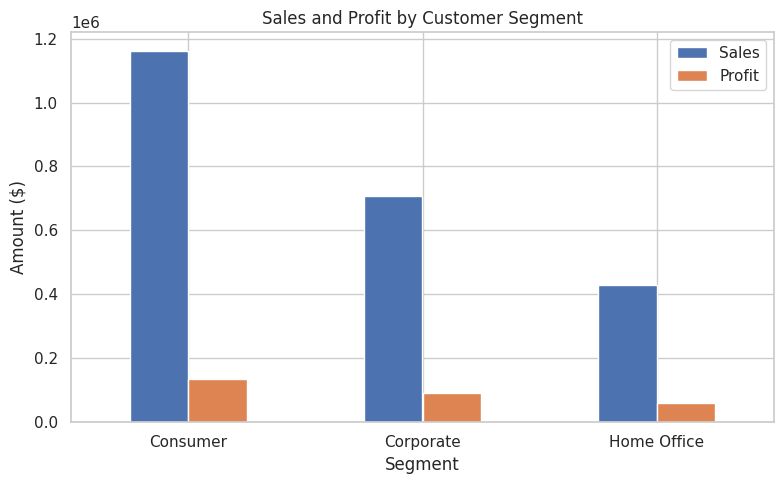

In [ ]:
segment = df.groupby("Segment").agg(Sales=("Sales","sum"), Profit=("Profit","sum"), Orders=("Order ID","nunique"))
segment["Profit Margin %"] = segment["Profit"] / segment["Sales"] * 100
display(segment.sort_values("Profit", ascending=False))

fig, ax = plt.subplots(figsize=(8,5))
segment[["Sales","Profit"]].plot(kind="bar", ax=ax)
ax.set_title("Sales and Profit by Customer Segment")
ax.set_ylabel("Amount ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

11.**Shiping Performance**

In [ ]:
shipping = df.groupby("Ship Mode").agg(Sales=("Sales","sum"), Profit=("Profit","sum"), Avg_Ship_Days=("Ship Days","mean"), Orders=("Order ID","nunique"))
shipping["Profit Margin %"] = shipping["Profit"] / shipping["Sales"] * 100
display(shipping.sort_values("Profit", ascending=False))

,Sales,Profit,Avg_Ship_Days,Orders,Profit Margin %
Ship Mode,,,,,
Standard Class,"1,358,215.74","164,088.79",5.01,2994,12.08
Second Class,"459,193.57","57,446.64",3.24,964,12.51
First Class,"351,428.42","48,969.84",2.18,787,13.93
Same Day,"128,363.12","15,891.76",0.04,264,12.38


12.**Discount VS Profitability**

Correlation between discount and profit: -0.219


,Sales,Profit,Avg_Profit,Avg_Discount,Orders,Profit Margin %
Discount Band,,,,,,
0%,"1,087,908.47","320,987.60",66.90,0.00,2644,29.51
1-10%,"54,369.35","9,029.18",96.06,0.10,89,16.61
11-20%,"792,152.89","91,756.30",24.74,0.20,2436,11.58
21-30%,"103,226.65","-10,369.28",-45.68,0.30,211,-10.05
31-40%,"130,911.24","-25,448.19",-109.22,0.39,211,-19.44
41-50%,"64,403.51","-22,999.54",-298.70,0.49,74,-35.71
51-60%,"6,644.70","-5,944.66",-43.08,0.60,127,-89.46
61-70%,"40,620.28","-40,075.36",-95.87,0.70,344,-98.66
71-80%,"16,963.76","-30,539.04",-101.80,0.80,250,-180.03


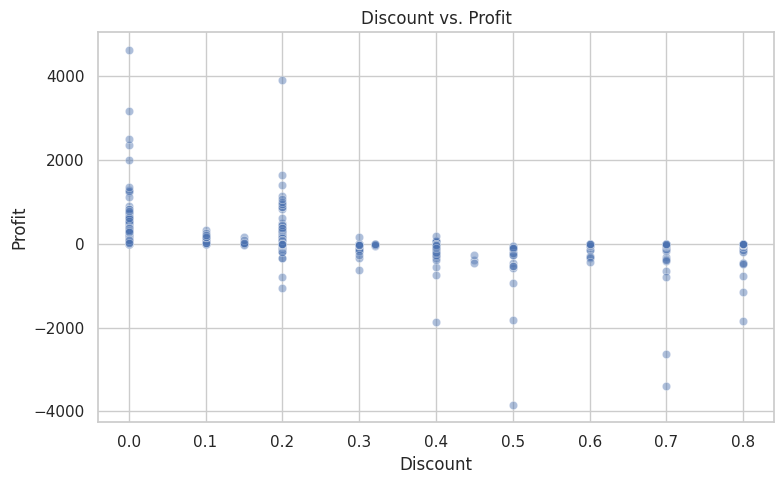

In [ ]:
corr = df["Discount"].corr(df["Profit"])
print(f"Correlation between discount and profit: {corr:.3f}")

discount_analysis = df.groupby("Discount Band", observed=True).agg(
    Sales=("Sales","sum"),
    Profit=("Profit","sum"),
    Avg_Profit=("Profit","mean"),
    Avg_Discount=("Discount","mean"),
    Orders=("Order ID","nunique")
)
discount_analysis["Profit Margin %"] = discount_analysis["Profit"] / discount_analysis["Sales"] * 100
display(discount_analysis)

fig, ax = plt.subplots(figsize=(8,5))
sns.scatterplot(data=df.sample(min(3000, len(df)), random_state=42), x="Discount", y="Profit", alpha=0.45, ax=ax)
ax.set_title("Discount vs. Profit")
plt.tight_layout()
plt.show()

13.**Pareto Analysis**(product analysis)

Number of profitable products: 1546
Products needed to reach 80% of positive product profit: 342


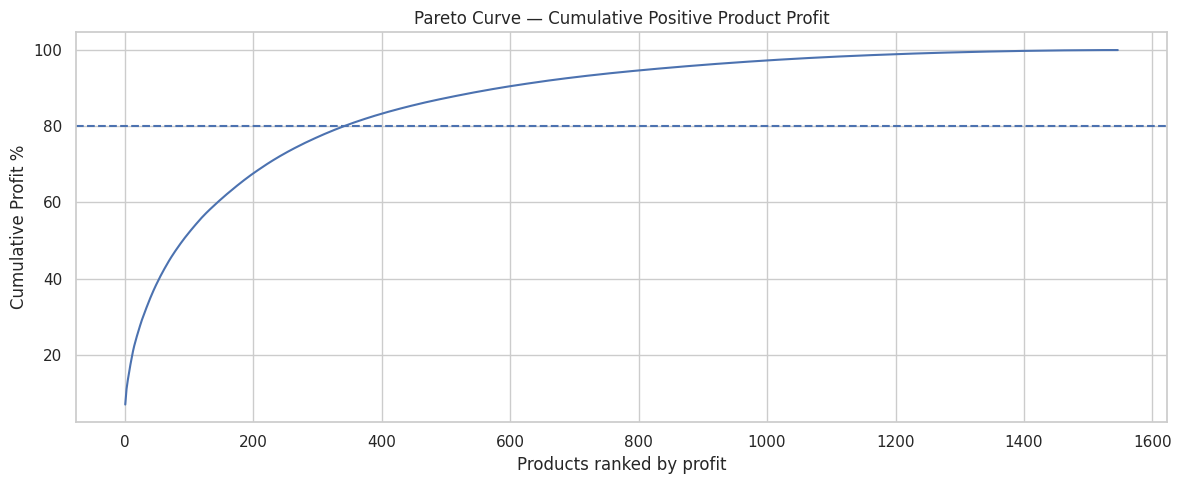

In [ ]:
product_profit = df.groupby("Product Name")["Profit"].sum().sort_values(ascending=False)
positive_profit = product_profit[product_profit > 0]
pareto = pd.DataFrame({"Profit": positive_profit})
pareto["Cumulative %"] = pareto["Profit"].cumsum() / pareto["Profit"].sum() * 100

print("Number of profitable products:", len(positive_profit))
print("Products needed to reach 80% of positive product profit:", (pareto["Cumulative %"] <= 80).sum() + 1)

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(range(1, len(pareto)+1), pareto["Cumulative %"])
ax.axhline(80, linestyle="--")
ax.set_title("Pareto Curve — Cumulative Positive Product Profit")
ax.set_xlabel("Products ranked by profit")
ax.set_ylabel("Cumulative Profit %")
plt.tight_layout()
plt.show()

14.**Corr and Outlier Analysis**

,Sales,Quantity,Discount,Profit
Sales,1.00,0.20,-0.03,0.48
Quantity,0.20,1.00,0.01,0.07
Discount,-0.03,0.01,1.00,-0.22
Profit,0.48,0.07,-0.22,1.00


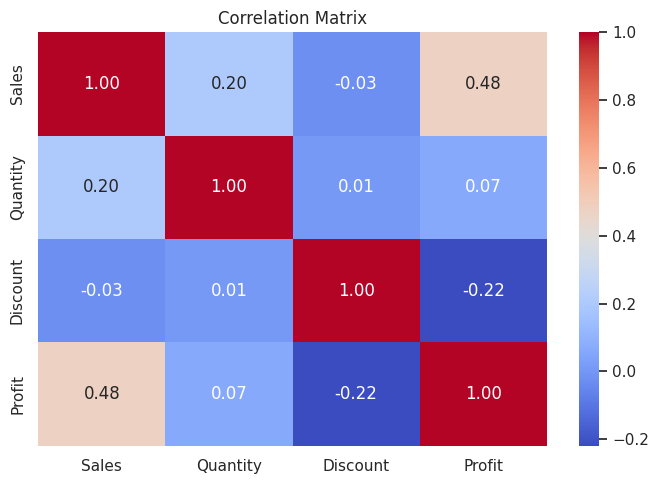

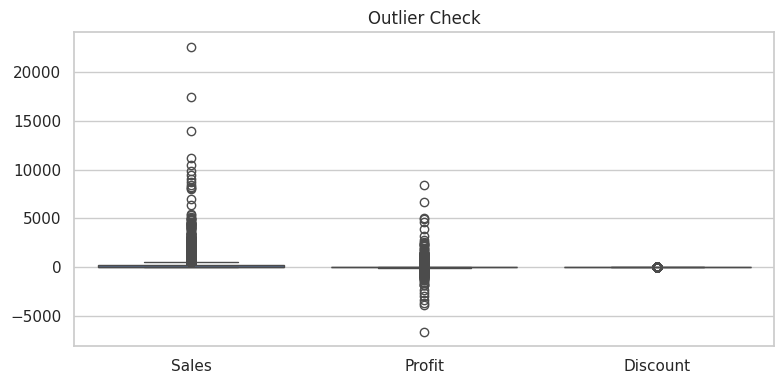

In [ ]:
numeric_cols = ["Sales", "Quantity", "Discount", "Profit"]
corr_matrix = df[numeric_cols].corr()
display(corr_matrix)

fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8,4))
sns.boxplot(data=df[["Sales","Profit","Discount"]], ax=ax)
ax.set_title("Outlier Check")
plt.tight_layout()
plt.show()

15.**Automated Key Insights**

In [ ]:
top_category = category["Profit"].idxmax()
bottom_category = category["Profit"].idxmin()
top_region = region["Profit"].idxmax()
bottom_region = region["Profit"].idxmin()
top_segment = segment["Profit"].idxmax()
bottom_subcat = subcat["Profit"].idxmin()
best_state = state["Profit"].idxmax()
worst_state = state["Profit"].idxmin()
worst_discount_band = discount_analysis["Profit Margin %"].idxmin()

# Calculate bottom_segment outside the f-string
bottom_segment = segment['Profit'].idxmin()

insights = [
    f"{top_category} is the most profitable category, while {bottom_category} has the lowest total category profit.",
    f"{top_region} is the most profitable region, while {bottom_region} has the lowest regional profit.",
    f"{top_segment} is the most profitable customer segment; {bottom_segment} contributes the least profit.",
    f"{bottom_subcat} is the weakest sub-category by total profit and should be reviewed for pricing, discounting, or cost issues.",
    f"{best_state} is the top state by profit, while {worst_state} is the lowest-performing state by profit.",
    f"The discount/profit correlation is {corr:.2f}; use the discount-band table to identify levels where margin deteriorates.",
    f"The discount band with the lowest observed profit margin is {worst_discount_band}.",
    f"There are {loss_lines:,} loss-making line items, making loss-driver analysis important for profitability improvement."
]
for i, insight in enumerate(insights, 1):
    print(f"{i}. {insight}")

1. Technology is the most profitable category, while Furniture has the lowest total category profit.
2. West is the most profitable region, while Central has the lowest regional profit.
3. Consumer is the most profitable customer segment; Home Office contributes the least profit.
4. Tables is the weakest sub-category by total profit and should be reviewed for pricing, discounting, or cost issues.
5. California is the top state by profit, while Texas is the lowest-performing state by profit.
6. The discount/profit correlation is -0.22; use the discount-band table to identify levels where margin deteriorates.
7. The discount band with the lowest observed profit margin is 71-80%.
8. There are 1,871 loss-making line items, making loss-driver analysis important for profitability improvement.


16 **Business Questions**

In [ ]:
#which product generate The highest loss
loss_products = (
    df[df["Profit"] < 0]
    .groupby("Product Name")
    .agg(
        Sales=("Sales", "sum"),
        Loss=("Profit", "sum"),
        Orders=("Order ID", "nunique")
    )
    .sort_values("Loss")
)

loss_products.head(1)

,Sales,Loss,Orders
Product Name,,,
Cubify CubeX 3D Printer Double Head Print,"6,299.98","-9,239.97",2


In [ ]:
#Which sub-categories generate the most losses?
loss_subcat = (
    df[df["Profit"] < 0]
    .groupby("Sub-Category")["Profit"]
    .sum()
    .sort_values()
)

loss_subcat

,Profit
Sub-Category,
Binders,"-38,510.50"
Tables,"-32,412.15"
Machines,"-30,118.67"
Bookcases,"-12,152.21"
Chairs,"-9,880.84"
Appliances,"-8,629.64"
Phones,"-7,530.62"
Furnishings,"-6,490.91"
Storage,"-6,426.30"


In [ ]:
#Does higher discount actually reduce profitability?
df.head(10)
# The  answer is yes more discount result to less profit the profit is depend on how many no of quantity customer buy ,apply discount on less quantity items

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Quantity,Discount,Profit,Year,Month,YearMonth,Ship Days,Profit Margin,Loss Making,Discount Band
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,2,0.00,41.91,2016,11,2016-11,3,0.16,False,0%
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,3,0.00,219.58,2016,11,2016-11,3,0.30,False,0%
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,2,0.00,6.87,2016,6,2016-06,4,0.47,False,0%
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,5,0.45,-383.03,2015,10,2015-10,7,-0.40,True,41-50%
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,2,0.20,2.52,2015,10,2015-10,7,0.11,False,11-20%
5,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,7,0.00,14.17,2014,6,2014-06,5,0.29,False,0%
6,7,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,4,0.00,1.97,2014,6,2014-06,5,0.27,False,0%
7,8,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,6,0.20,90.72,2014,6,2014-06,5,0.10,False,11-20%
8,9,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,3,0.20,5.78,2014,6,2014-06,5,0.31,False,11-20%
9,10,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,5,0.00,34.47,2014,6,2014-06,5,0.30,False,0%


In [ ]:
#Which category + sub-category combinations are most profitable?
df.groupby(
    ["Category", "Sub-Category"]
).agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
).sort_values("Profit", ascending=False)

Sales     Profit  Quantity
Category        Sub-Category                                
Technology      Copiers      149,528.03  55,617.82       234
                Phones       330,007.05  44,515.73      3289
                Accessories  167,380.32  41,936.64      2976
Office Supplies Paper         78,479.21  34,053.57      5178
                Binders      203,412.73  30,221.76      5974
Furniture       Chairs       328,449.10  26,590.17      2356
Office Supplies Storage      223,843.61  21,278.83      3158
                Appliances   107,532.16  18,138.01      1729
Furniture       Furnishings   91,705.16  13,059.14      3563
Office Supplies Envelopes     16,476.40   6,964.18       906
                Art           27,118.79   6,527.79      3000
                Labels        12,486.31   5,546.25      1400
Technology      Machines     189,238.63   3,384.76       440
Office Supplies Fasteners      3,024.28     949.52       914
                Supplies      46,673.54  -1,189.10       647
Furniture       Bookcases    114,880.00  -3,472.56       868
                Tables       206,965.53 -17,725.48      1241

In [ ]:
#Which customers are profitable, not just high-sales?
# Customer-level analysis
customer = (
    df.groupby("Customer Name")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Orders=("Order ID", "nunique")
      )
)

# Calculate profit margin
customer["Profit Margin"] = (
    customer["Profit"] / customer["Sales"] * 100
)

# Median values used as benchmarks
sales_median = customer["Sales"].median()
margin_median = customer["Profit Margin"].median()

# Customer classification
def classify_customer(row):

    # Priority 1: Customers making an overall loss
    if row["Profit"] < 0:
        return "Money-Loser"

    # High sales + healthy margin
    elif row["Sales"] >= sales_median and row["Profit Margin"] >= margin_median:
        return "Star"

    # High sales + thin margin
    elif row["Sales"] >= sales_median and row["Profit Margin"] < margin_median:
        return "Vanity"

    # Lower sales + healthy margin
    else:
        return "Efficient"


customer["Customer Type"] = customer.apply(
    classify_customer,
    axis=1
)

# Display customer classification
customer.sort_values(
    ["Customer Type", "Profit"],
    ascending=[True, False]
).head(20)

,Sales,Profit,Orders,Profit Margin,Customer Type
Customer Name,,,,,
Karen Carlisle,"2,120.95",846.12,6,39.89,Efficient
Neoma Murray,"2,161.98",788.95,10,36.49,Efficient
Pauline Johnson,"1,824.23",683.00,7,37.44,Efficient
Becky Pak,"1,697.86",647.38,6,38.13,Efficient
Roy Phan,"2,170.72",594.59,8,27.39,Efficient
Phillip Flathmann,"2,206.13",591.31,5,26.80,Efficient
Dave Poirier,"2,215.00",563.18,8,25.43,Efficient
Lisa DeCherney,"1,961.93",557.17,4,28.40,Efficient
Duane Noonan,"2,139.79",540.54,7,25.26,Efficient


In [ ]:
#summary table
customer_summary = (
    customer.groupby("Customer Type")
    .agg(
        Customers=("Customer Type", "count"),
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Avg_Profit_Margin=("Profit Margin", "mean")
    )
    .sort_values("Total_Profit", ascending=False)
)

customer_summary

,Customers,Total_Sales,Total_Profit,Avg_Profit_Margin
Customer Type,,,,
Star,206,"1,017,896.37","253,351.03",23.64
Efficient,309,"361,657.39","61,974.47",18.35
Vanity,123,"525,696.69","42,295.99",8.02
Money-Loser,155,"391,950.41","-71,224.47",-17.96


In [ ]:
#which product have high sales but negetive profit
product["Profit Margin %"] = product["Profit"] / product["Sales"] * 100

product[
    (product["Sales"] > product["Sales"].median()) &
    (product["Profit"] < 0)
].sort_values("Sales", ascending=False)

,Sales,Profit,Quantity,Profit Margin %
Product Name,,,,
Cisco TelePresence System EX90 Videoconferencing Unit,"22,638.48","-1,811.08",6,-8.00
GBC DocuBind P400 Electric Binding System,"17,965.07","-1,878.17",27,-10.45
High Speed Automatic Electric Letter Opener,"17,030.31",-262.00,11,-1.54
Lexmark MX611dhe Monochrome Laser Printer,"16,829.90","-4,589.97",18,-27.27
Martin Yale Chadless Opener Electric Letter Opener,"16,656.20","-1,299.18",22,-7.80
...,...,...,...,...
Eldon Cleatmat Chair Mats for Medium Pile Carpets,344.10,-42.18,8,-12.26
"Brother MFC-9340CDW LED All-In-One Printer, Copier Scanner",341.99,-319.19,3,-93.33
SanDisk Ultra 16 GB MicroSDHC Class 10 Memory Card,329.95,-48.58,31,-14.72


In [ ]:
#what percentage of orders are loss making
total_line_items = len(df)
loss_making_percentage = (loss_lines / total_line_items) * 100
print(f"Percentage of loss-making line items: {loss_making_percentage:.2f}%")

Percentage of loss-making line items: 18.72%


In [ ]:
#Which states have high sales but poor profitability solve this problem
# State-level analysis
state_analysis = (
    df.groupby("State")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Orders=("Order ID", "nunique")
      )
)

# Calculate profit margin
state_analysis["Profit Margin"] = (
    state_analysis["Profit"] /
    state_analysis["Sales"] * 100
)

# Median benchmarks
sales_median = state_analysis["Sales"].median()
margin_median = state_analysis["Profit Margin"].median()

# Find high-sales but poor-profitability states
high_sales_low_profit = state_analysis[
    (state_analysis["Sales"] >= sales_median) &
    (state_analysis["Profit Margin"] < margin_median)
].sort_values("Profit Margin")

high_sales_low_profit

def classify_state(row):

    if row["Profit"] < 0:
        return "Loss-Making"

    elif (
        row["Sales"] >= sales_median and
        row["Profit Margin"] < margin_median
    ):
        return "High Sales - Poor Profitability"

    elif (
        row["Sales"] >= sales_median and
        row["Profit Margin"] >= margin_median
    ):
        return "High Sales - Healthy Profitability"

    else:
        return "Lower Sales"


state_analysis["Performance"] = state_analysis.apply(
    classify_state,
    axis=1
)

state_analysis.sort_values(
    ["Performance", "Sales"],
    ascending=[True, False]
)

,Sales,Profit,Orders,Profit Margin,Performance
State,,,,,
Michigan,"76,269.61","24,463.19",117,32.07,High Sales - Healthy Profitability
Virginia,"70,636.72","18,597.95",115,26.33,High Sales - Healthy Profitability
Indiana,"53,555.36","18,382.94",73,34.33,High Sales - Healthy Profitability
Georgia,"49,095.84","16,250.04",91,33.10,High Sales - Healthy Profitability
Kentucky,"36,591.75","11,199.70",61,30.61,High Sales - Healthy Profitability
New Jersey,"35,764.31","9,772.91",61,27.33,High Sales - Healthy Profitability
Wisconsin,"32,114.61","8,401.80",53,26.16,High Sales - Healthy Profitability
Minnesota,"29,863.15","10,823.19",44,36.24,High Sales - Healthy Profitability
Delaware,"27,451.07","9,977.37",44,36.35,High Sales - Healthy Profitability


**IMP Solved Questions**
1.What is the overall business performance?

2.How are Sales and Profit changing over time?

3.Which Categories and Sub-Categories are most profitable?

4.Which Products generate the most and least profit?

5.Which Customers are genuinely profitable?

6.Which States have high Sales but poor Profitability?

7.Which Customer Segment is most valuable?

8.Does Discount affect Profitability?

9.Which Shipping Mode provides the best balance of cost/time and profitability?

10.Where is the business losing money, and what are the major contributors?

**Busines Recomendation**

1."Profitability depends on a combination of quantity, selling price, discount, product mix and associated costs. Therefore, discount decisions should not be based on quantity alone."

2.Focus on profitable products(High Sales + High Profit + Healthy Profit Margin)   

3.Review consistently loss-making and low-margin products. Consider repricing, reducing discounts, controlling costs, or discontinuing products that remain unprofitable after review."

4."Prioritize categories and sub-categories that consistently generate high profit and healthy margins, while investigating poorly performing sub-categories for pricing, discount and product-mix issues."

5."Customer value should be evaluated using both revenue and profitability. High-sales customers should not automatically be considered the most valuable, as some may generate thin or negative margins."

**Star → retain and prioritize
Efficient → nurture and grow
Vanity → review discounts/pricing
Money-Loser → investigate profitability**

6.Use targeted discounts based on product demand, quantity, margin and profitability rather than applying the same discount strategy to all products."

7."Investigate states with high sales but poor profitability. Review discount levels, product mix, shipping costs and pricing in these regions."

8."Superstore should avoid evaluating performance based solely on sales. Product, customer, geographic and discount strategies should be evaluated using both revenue and profitability."



**Final Conclusion**

Superstore should move from a sales-focused strategy to a profitability-focused strategy. Sustainable growth should come from selling the right products to the right customers, maintaining healthy margins, using discounts strategically, and continuously identifying and addressing sources of loss.